## Top hBN slitghly thinner than bottom 
## Back gate wider than top gate 
## 250 nm cut EBL --> Real one probably 150 nm

## Import the modules you need (this does not need to change)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import glob
import os
import matplotlib.cm as cm
import math as math
from scipy import signal
from scipy.fftpack import fft, ifft
from scipy.signal import savgol_filter
from collections import Counter
from ipywidgets import interactive
import ipympl
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA
import matplotlib.ticker as mticker

from scipy.integrate import simps
from numpy import trapz
import matplotlib.ticker as ticker

import matplotlib 
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import time

class Object():
    pass

import _pickle as pickle

In [2]:
 plt.rcParams["font.family"] = "arial"

In [3]:
%matplotlib inline
import LDQM_dataplot
import Superconductor_analysis
import TB32_Ic_analysis
import homemade_functions 
import JJ_current_distribution
import QuantumGeometry

savename='C:/jdiez_local/LDQM/a. Data/2023 April/'
savecount=1

orig_cmap = matplotlib.cm.RdBu_r
mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

font=16

def update_modules():
    
    importlib.reload(LDQM_dataplot)
    importlib.reload(Superconductor_analysis)
    importlib.reload(TB32_Ic_analysis)
    importlib.reload(homemade_functions)
    importlib.reload(JJ_current_distribution)
    importlib.reload(QuantumGeometry)


C:\jdiez_local\Code\LDQM_dataplot.py:644: UserWarning: Trying to register the cmap 'shiftedcmap' which already exists.
  plt.register_cmap(cmap=newcmap)


In [4]:
update_modules()

from homemade_functions import runningMeanFast
from homemade_functions import plot_pre,plot_map,plot_line,plot_premap
from Superconductor_analysis import parula_cmap as parula
from Superconductor_analysis import derivative_dvdi, Ic_derivative 
from QuantumGeometry import get_Ic_minimum, get_Ic_maximums

## All the functions for plotting are in here

In [5]:
import LDQM_dataplot

importlib.reload(LDQM_dataplot)


<module 'LDQM_dataplot' from 'C:\\jdiez_local\\Code\\LDQM_dataplot.py'>

In [6]:
savename='C:/Users/jdiez/LDQM/a. Data/Ju1/Fig/'
savecount=1
%matplotlib inline

In [7]:
cm_data = [[0.2081, 0.1663, 0.5292], [0.2116238095, 0.1897809524, 0.5776761905], 
 [0.212252381, 0.2137714286, 0.6269714286], [0.2081, 0.2386, 0.6770857143], 
 [0.1959047619, 0.2644571429, 0.7279], [0.1707285714, 0.2919380952, 
  0.779247619], [0.1252714286, 0.3242428571, 0.8302714286], 
 [0.0591333333, 0.3598333333, 0.8683333333], [0.0116952381, 0.3875095238, 
  0.8819571429], [0.0059571429, 0.4086142857, 0.8828428571], 
 [0.0165142857, 0.4266, 0.8786333333], [0.032852381, 0.4430428571, 
  0.8719571429], [0.0498142857, 0.4585714286, 0.8640571429], 
 [0.0629333333, 0.4736904762, 0.8554380952], [0.0722666667, 0.4886666667, 
  0.8467], [0.0779428571, 0.5039857143, 0.8383714286], 
 [0.079347619, 0.5200238095, 0.8311809524], [0.0749428571, 0.5375428571, 
  0.8262714286], [0.0640571429, 0.5569857143, 0.8239571429], 
 [0.0487714286, 0.5772238095, 0.8228285714], [0.0343428571, 0.5965809524, 
  0.819852381], [0.0265, 0.6137, 0.8135], [0.0238904762, 0.6286619048, 
  0.8037619048], [0.0230904762, 0.6417857143, 0.7912666667], 
 [0.0227714286, 0.6534857143, 0.7767571429], [0.0266619048, 0.6641952381, 
  0.7607190476], [0.0383714286, 0.6742714286, 0.743552381], 
 [0.0589714286, 0.6837571429, 0.7253857143], 
 [0.0843, 0.6928333333, 0.7061666667], [0.1132952381, 0.7015, 0.6858571429], 
 [0.1452714286, 0.7097571429, 0.6646285714], [0.1801333333, 0.7176571429, 
  0.6424333333], [0.2178285714, 0.7250428571, 0.6192619048], 
 [0.2586428571, 0.7317142857, 0.5954285714], [0.3021714286, 0.7376047619, 
  0.5711857143], [0.3481666667, 0.7424333333, 0.5472666667], 
 [0.3952571429, 0.7459, 0.5244428571], [0.4420095238, 0.7480809524, 
  0.5033142857], [0.4871238095, 0.7490619048, 0.4839761905], 
 [0.5300285714, 0.7491142857, 0.4661142857], [0.5708571429, 0.7485190476, 
  0.4493904762], [0.609852381, 0.7473142857, 0.4336857143], 
 [0.6473, 0.7456, 0.4188], [0.6834190476, 0.7434761905, 0.4044333333], 
 [0.7184095238, 0.7411333333, 0.3904761905], 
 [0.7524857143, 0.7384, 0.3768142857], [0.7858428571, 0.7355666667, 
  0.3632714286], [0.8185047619, 0.7327333333, 0.3497904762], 
 [0.8506571429, 0.7299, 0.3360285714], [0.8824333333, 0.7274333333, 0.3217], 
 [0.9139333333, 0.7257857143, 0.3062761905], [0.9449571429, 0.7261142857, 
  0.2886428571], [0.9738952381, 0.7313952381, 0.266647619], 
 [0.9937714286, 0.7454571429, 0.240347619], [0.9990428571, 0.7653142857, 
  0.2164142857], [0.9955333333, 0.7860571429, 0.196652381], 
 [0.988, 0.8066, 0.1793666667], [0.9788571429, 0.8271428571, 0.1633142857], 
 [0.9697, 0.8481380952, 0.147452381], [0.9625857143, 0.8705142857, 0.1309], 
 [0.9588714286, 0.8949, 0.1132428571], [0.9598238095, 0.9218333333, 
  0.0948380952], [0.9661, 0.9514428571, 0.0755333333], 
 [0.9763, 0.9831, 0.0538]]

parula_map = LinearSegmentedColormap.from_list('parula', cm_data)

## May 2021

# Fraunhofers 

In [8]:
importlib.reload(LDQM_dataplot)

##dvdiF_directory = 'C:/Users/jdiez/LDQM/a. Data/2021 May'
dvdiF_directory = 'C:/jdiez_local/LDQM/a. Data/2021 May'
dvdiF_folder='/Ju1/SCS-Fraunhofers/'
dvdiF_directory= dvdiF_directory+dvdiF_folder

dvdiF_files=[
       'J-Ju1_Fraunhofer-SCS_35mK_1nA_I(7-18)_Rxx1Amplified(15-17)_Rxx2Amp(5-1)_VBg(-1p12V)_VTGs(-147mV)_m-B-Idc.txt',
             'J-Ju1_Fraunhofer_SCS_Bdn_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-147mV)_Vbg(-1p12V)_mB_Idc.txt',
             'J-Ju1_Fraunhofer_SCS_Bdn_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-147mV)_Vbg(-1p12V)_mB_Idc_2.txt',
       'J-Ju1_Fraunhofer-SCS_35mK_1nA_I(7-18)_Rxx1Amplified(15-17)_Rxx2Amp(5-1)_VBg(-1p12V)_VTGs(-147mV)_B(0Tafter100mT)_Idc_updn.txt',
        'J-Ju1_Fraunhofer-SCS_35mK_1nA_I(7-18)_Rxx1Amplified(15-17)_Rxx2Amp(5-1)_VBg(-1p12V)_VTGs(-147mV)_B(0Tafter-100mT)_Idc_updn.txt',
]


dvdiF_obj = {} #stores all the data
dvdi_raw ={} #store the xaxis data for plotting
dvdiF_variables={} #store the data to plot in the right units
dvdiF_name={}

# All IV curves
for i in range(0,3):
    file=dvdiF_directory+dvdiF_files[i]
    dvdiF_obj['data'+str(i)], dvdiF_variables['data'+str(i)],dvdiF_name['data'+str(i)]=LDQM_dataplot.plot_map_fromfiles(file)
for i in range(3,5):
    file=dvdiF_directory+dvdiF_files[i]
    dvdiF_obj['data'+str(i)], dvdiF_variables['data'+str(i)],dvdiF_name['data'+str(i)]=LDQM_dataplot.plot_lines_fromfiles(file,x_variable=1)
    

In [9]:
kb=1.38E-23/1.602E-19 # in eV
gap=kb*1.76*1.5
gap
Ic=1200E-9
Rn=0.8E3

Ic*Rn/gap


4.221343873517785

In [10]:
savecount=1

C:\Users\j.diez\AppData\Local\Temp\ipykernel_39912\4149575901.py:41: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = plt.pcolormesh(y,x,z1517,cmap=mycolor)


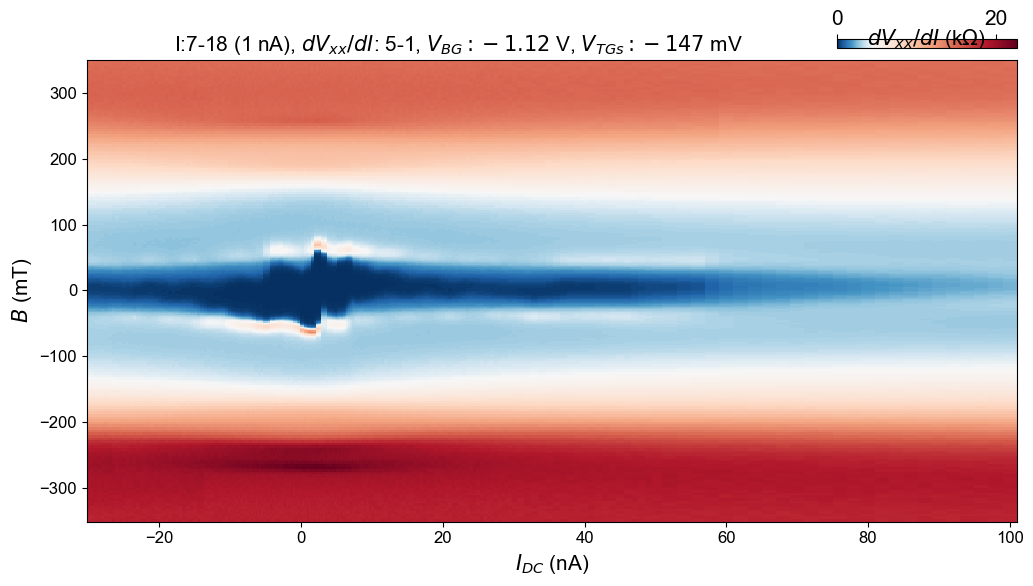

C:\Users\j.diez\AppData\Local\Temp\ipykernel_39912\4149575901.py:71: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = plt.pcolormesh(x,y,z51,cmap=mycolor)


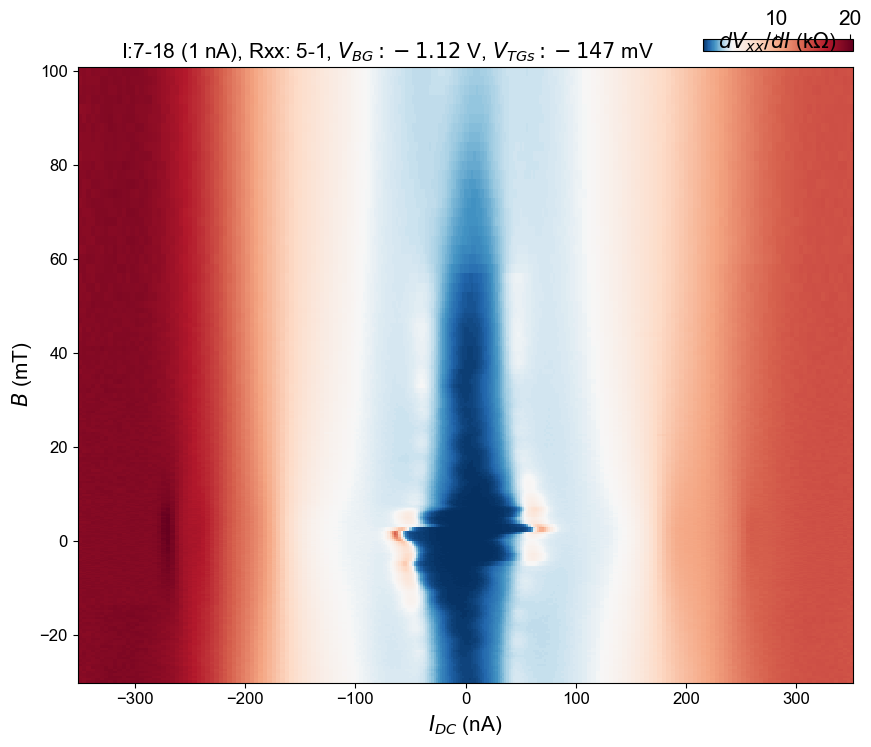

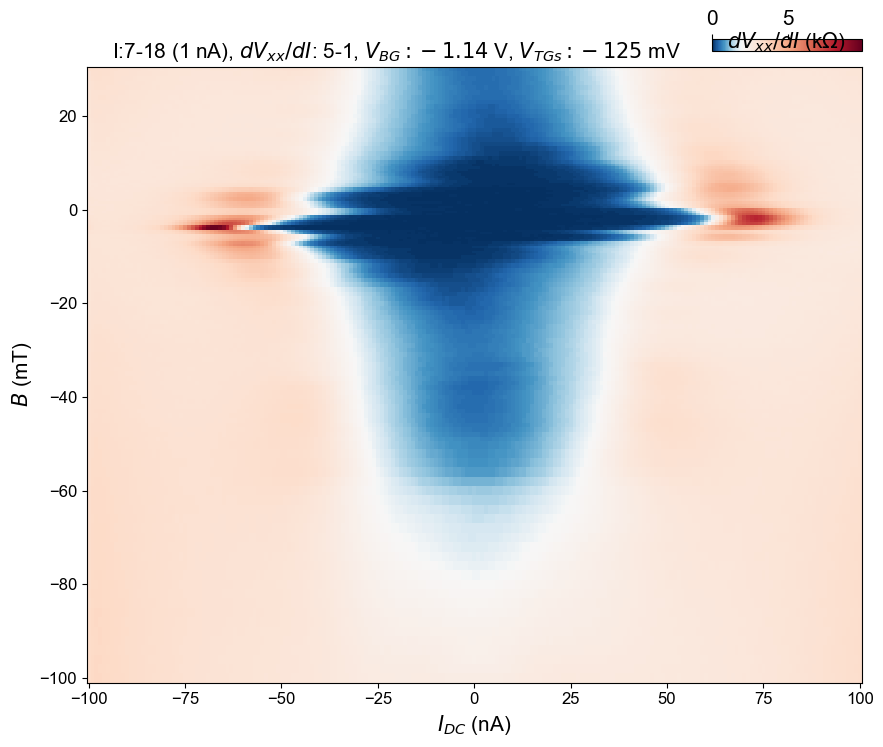

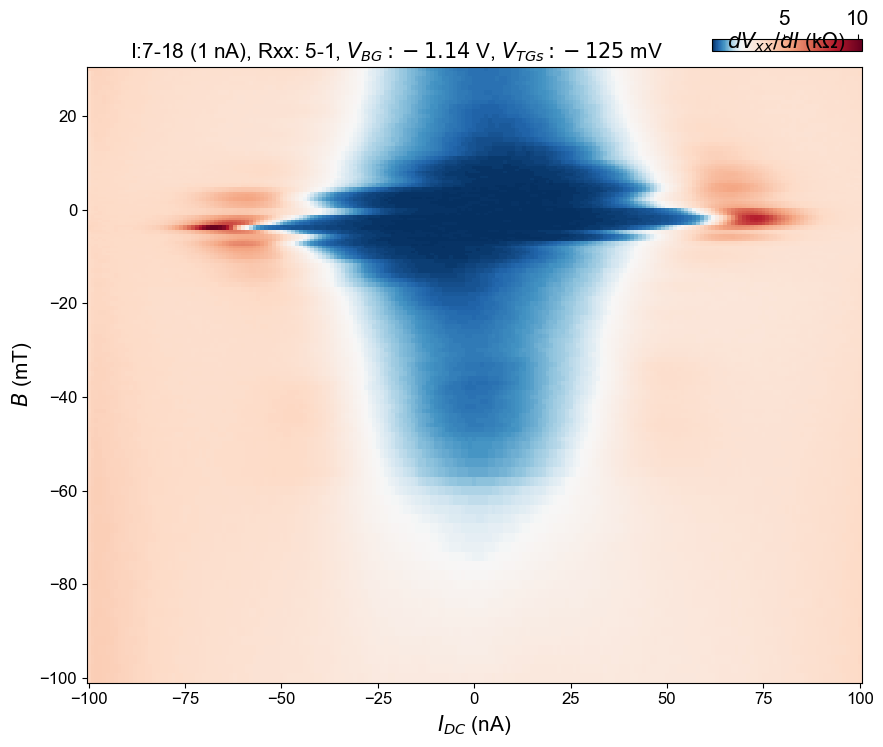

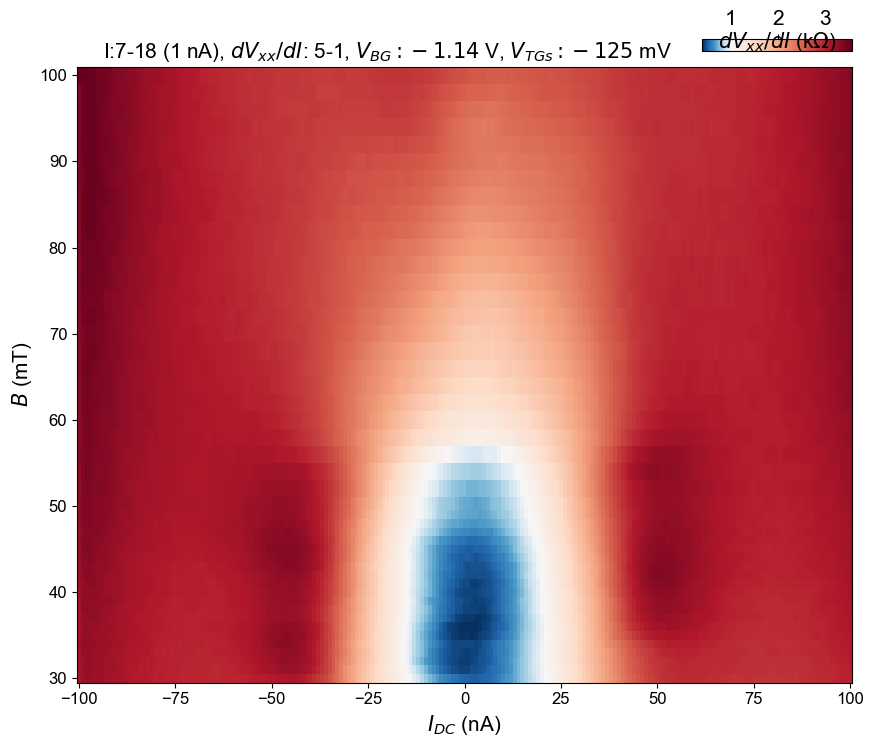

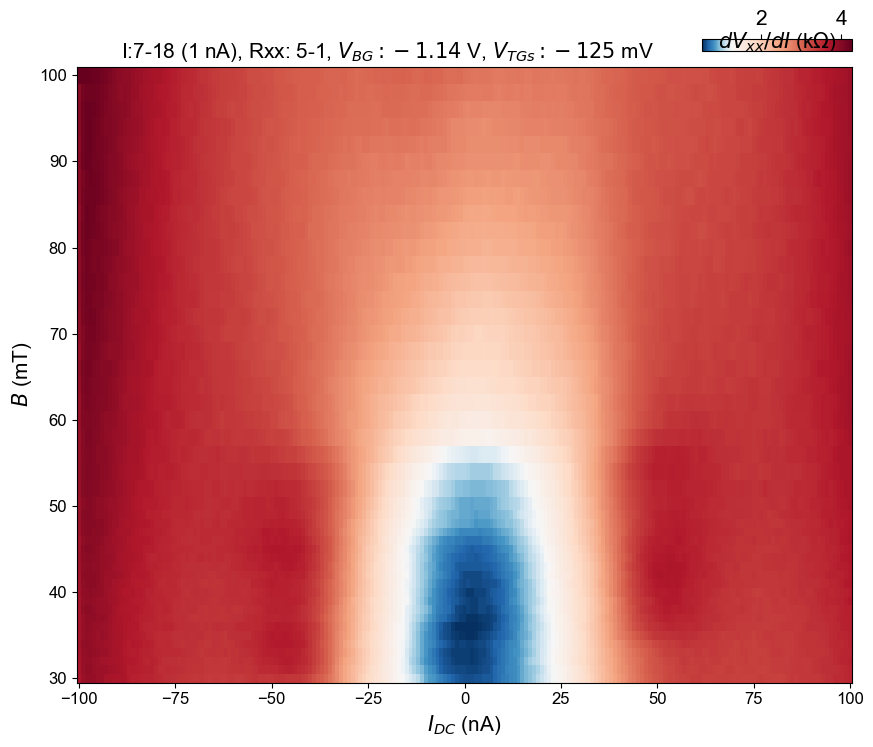

In [11]:
savecount=1
# Data
x=dvdiF_obj['data0'].DCsource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj['data0'].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj['data0'].Rxx4X # in nA
z1517=dvdiF_obj['data0'].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj['data0'].Rxx_2_Ampx10X/I718/1000/10 # in kOhm

x2=dvdiF_obj['data1'].DCSource1V100nASourcevoltage*100 # in nA
y2=dvdiF_obj['data1'].MagnetFieldsetpoint*1000
yBG2=-1.2-y*0.88 # in V
I7182=dvdiF_obj['data1'].Rxx4X # in nA
z15172=dvdiF_obj['data1'].Rxx1_Ampx10X/I7182/1000/10 # in kOhm
z512=dvdiF_obj['data1'].Rxx2_Ampx10X/I7182/1000/10 # in kOhm

x3=dvdiF_obj['data2'].DCSource1V100nASourcevoltage*100 # in nA
y3=dvdiF_obj['data2'].MagnetFieldsetpoint*1000
yBG3=-1.2-y*0.88 # in V
I7183=dvdiF_obj['data2'].Rxx4X # in nA
z15173=dvdiF_obj['data2'].Rxx1_Ampx10X/I7183/1000/10 # in kOhm
z513=dvdiF_obj['data2'].Rxx2_Ampx10X/I7183/1000/10 # in kOhm
# Fig params to save and color 

font = 15
linefits=True
if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.2,orig_cmap)

# Start the figure 

fig = plt.figure(figsize=(12,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), $dV_{xx}/dI$: 5-1, $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.4,0.92),color='k')

plt.show()

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x,y,z51,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), Rxx: 5-1, $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.4,0.92))

plt.show()


# Fig params to save and color 

font = 15
linefits=True
if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.2,orig_cmap)

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x2,y2,z15172,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), $dV_{xx}/dI$: 5-1, $V_{BG}:-1.14$ V, $V_{TGs}:-125$ mV',fontsize=font,position=(0.4,0.92),color='k')

plt.show()

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x2,y2,z512,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), Rxx: 5-1, $V_{BG}:-1.14$ V, $V_{TGs}:-125$ mV',fontsize=font,position=(0.4,0.92))

plt.show()

### Going field the other way

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x3,y3,z15173,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), $dV_{xx}/dI$: 5-1, $V_{BG}:-1.14$ V, $V_{TGs}:-125$ mV',fontsize=font,position=(0.4,0.92),color='k')

plt.show()

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x3,y3,z513,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), Rxx: 5-1, $V_{BG}:-1.14$ V, $V_{TGs}:-125$ mV',fontsize=font,position=(0.4,0.92))

plt.show()

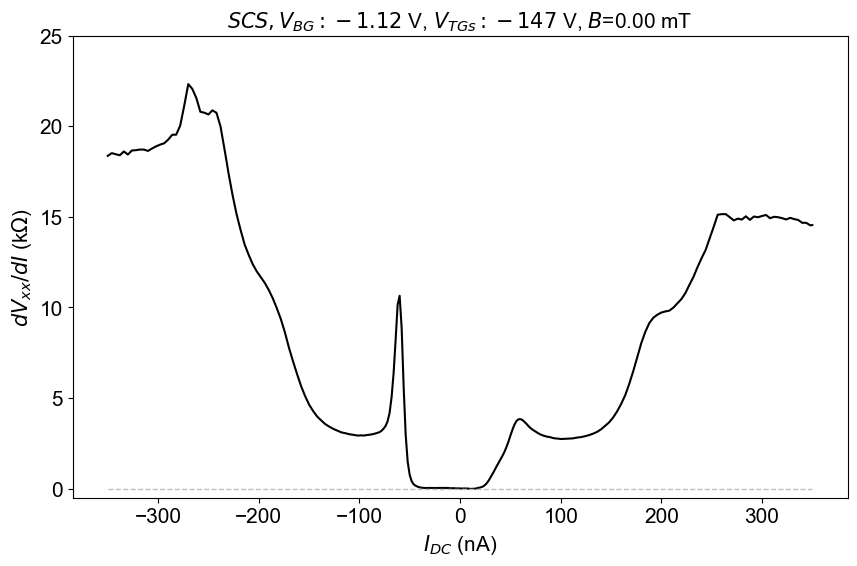

In [12]:
# Plot the line at 0 field 
plt.figure(figsize=(10,6))
line=125
plt.plot(x[line],z1517[line],'k',label='$SCS, V_{BG}:-1.12$ V, $V_{TGs}:147$ mV, $B$='+'{0:.2f}'.format(y[line,0])+' mT')

#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
plt.title('$SCS, V_{BG}:-1.12$ V, $V_{TGs}:-147$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))
plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font)
plt.ylim(-0.5,25)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)

if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg-1p12_VTgs147V_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()

C:\Users\j.diez\AppData\Local\Temp\ipykernel_39912\2083828377.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmax=8,vmin=0)


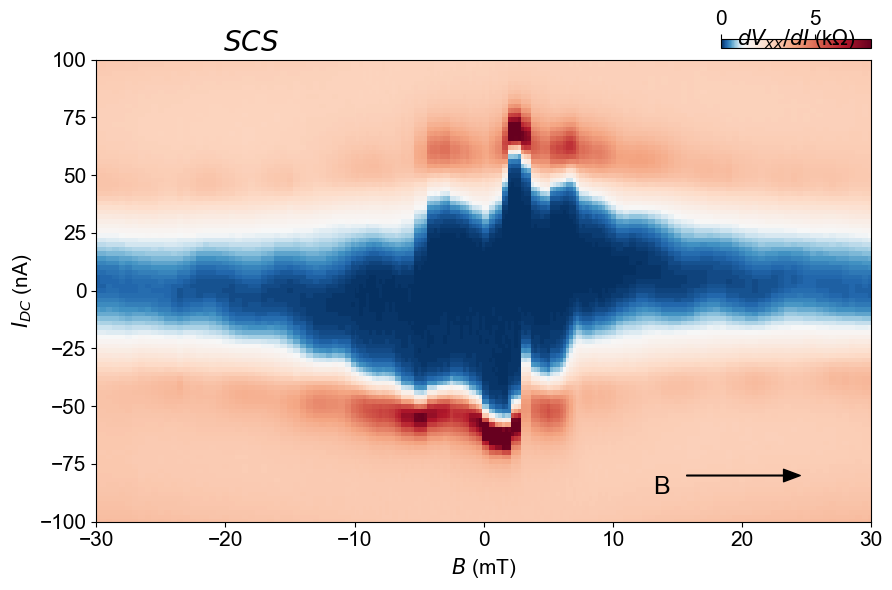

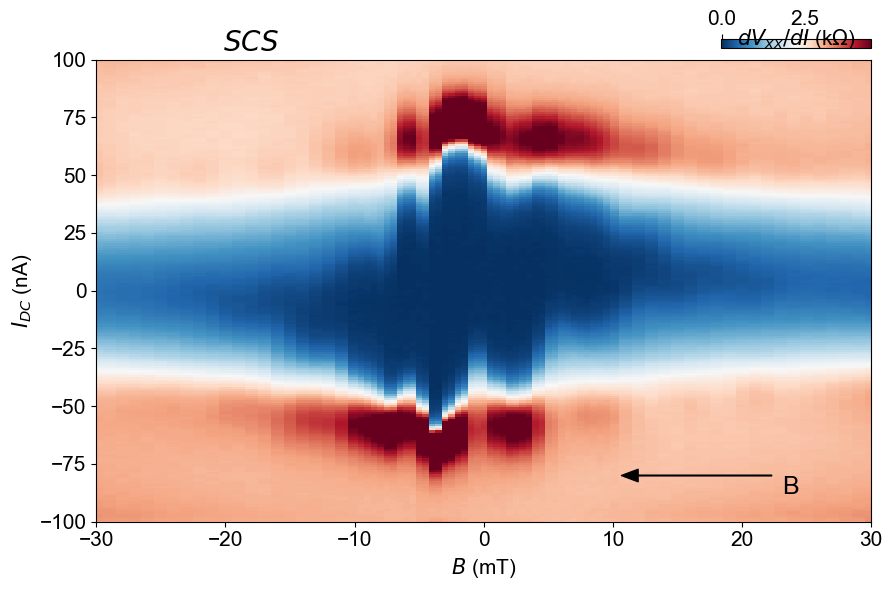

In [13]:
if savecount==0:
    save=True
else:
    save=False

orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.15,orig_cmap,0,1)

# Start the figure 
font=15
fig = plt.figure(figsize=(10,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmax=8,vmin=0)
#im = plt.pcolormesh(x,y,z1517,cmap=mycolor,vmax=5,shading='gouraud')
ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=font)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.7,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

ax.set_ylim(-100,100)
ax.set_xlim(-30,30)

ax.set_title('$SCS$' ,fontsize=20,position=(0.2,0.9))
ax.annotate('B ', xy=(25,-80),xytext=(15, -80), arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),horizontalalignment='right', verticalalignment='top',fontsize=18)
if save:
    plt.savefig(savename+'JJBF_SCS_Vbg-1p12_Bup_I7-18_Rxx1517_lowBfocus'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap,0,1)

# Start the figure 
savecount=savecount-1
fig = plt.figure(figsize=(10,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y2,x2,z15172,cmap=mycolor,vmax=4.5)
#im = plt.pcolormesh(x,y,z1517,cmap=mycolor,vmax=5,shading='gouraud')
ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=font)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.7,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

ax.set_ylim(-100,100)
ax.set_xlim(-30,30)
ax.set_title('$SCS$' ,fontsize=20,position=(0.2,0.9))
ax.annotate('B ', xy=(10,-80),
            xytext=(25, -80),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=18
            )
if save:
    plt.savefig(savename+'JJBF_SCS_-Vbg1p12_Bdn_I7-18_Rxx1517_lowBfocus'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()

# Plot the 0 field state after going to up and down fields

In [14]:
savecount=1

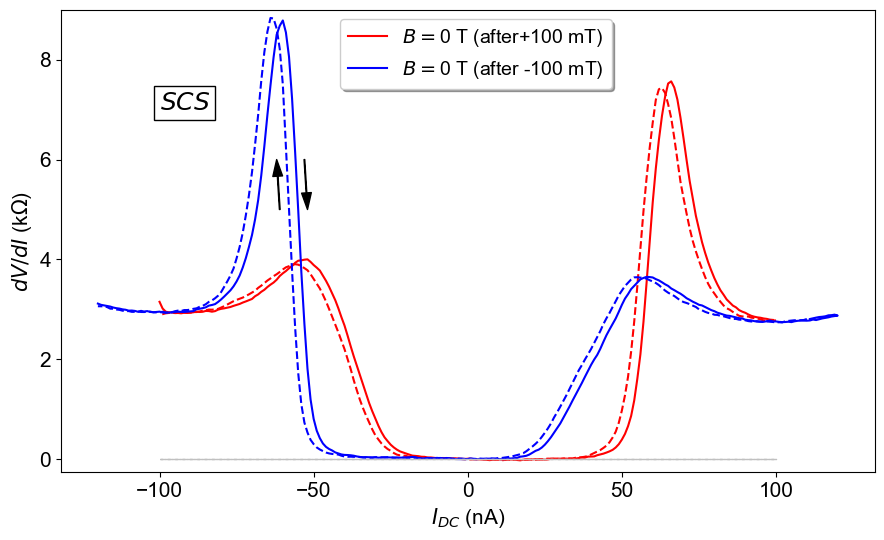

area red right =195.6159434546439 $\mu V$, area red left 204.070522698254
area blue right =209.28516445047214 $\mu V$, area blue left 218.04275301972342
$I_cR_N$ is 300uV


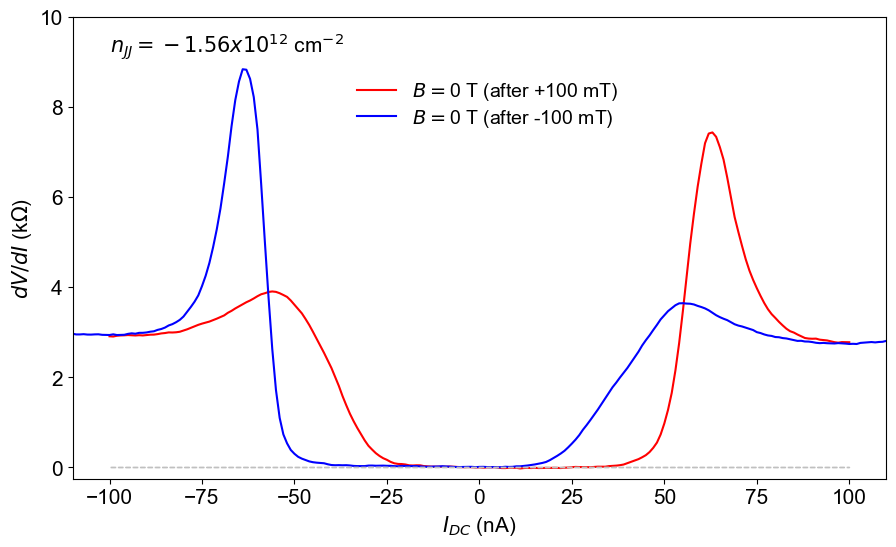

In [15]:
# Data
x1=dvdiF_obj['data3'].DCsource1V100nASourcevoltage*100 # in nA
I7181=dvdiF_obj['data3'].Rxx4X # in nA
z15171=dvdiF_obj['data3'].Rxx1_Ampx10X/I7181/1000/10 # in kOhm
z511=dvdiF_obj['data3'].Rxx_2_Ampx10X/I7181/1000/10 # in kOhm

x2=dvdiF_obj['data4'].DCsource1V100nASourcevoltage*100 # in nA
I7182=dvdiF_obj['data4'].Rxx4X # in nA
z15172=dvdiF_obj['data4'].Rxx1_Ampx10X/I7182/1000/10 # in kOhm
z512=dvdiF_obj['data4'].Rxx_2_Ampx10X/I7182/1000/10 # in kOhm

# Fig params to save and color 

font = 15

if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap,0,1)

# Start the figure 

fig = plt.figure(figsize=(10.5,6))

plt.plot(x1[:200],z15171[:200],'r',label='$B= $0 T (after+100 mT)')
plt.plot(x1[200:],z15171[200:],'r--')
plt.plot(x2[:250],z15172[:250],'b',label='$B= $0 T (after -100 mT)')
plt.plot(x2[250:],z15172[250:],'b--')
plt.legend(loc='upper center', bbox_to_anchor=(0.51,1.0), shadow=True, ncol=1,fontsize=14)
plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV/dI$ (k$\Omega$)',fontsize=font)
#plt.title('$I:7-18, R_{xx}: 17-15, V_{BG}=-1.25, V_{TG}=-0$ V',fontsize=14)
plt.text(-100, 7,'$SCS$',color='k',fontsize=18,weight='bold',bbox=dict(facecolor='w',edgecolor='k'))
plt.ylim(-0.25,9)
plt.annotate('', xy=(-52,5),
            xytext=(-53, 6),
            arrowprops=dict(color='k',width=0.5,headwidth=7),
            horizontalalignment='right', verticalalignment='top',fontsize=18,color='k'
            )
plt.annotate('', xy=(-62,6),
            xytext=(-61, 5),
            arrowprops=dict(color='k',width=0.5,headwidth=7),
            horizontalalignment='right', verticalalignment='top',fontsize=18,color='k'
            )
#plt.xlim(-50,+50)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.plot(x1,x1*0,'silver',linestyle='dashed',linewidth=1)

if save:
    plt.savefig(savename+'JJBF_SCS_-Vbg1p12_dVdI_after+-100mT_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()


# Compute the area using the composite simpons method and compare to IcRn.
IcRn=100*3

area_redrigth = simps(z15171[100:200],x1[100:200])
area_redleft = simps(z15171[5:100],x1[5:100])

area_bluerigth = simps(z15172[120:225],x2[120:225])
area_blueleft = simps(z15172[20:120],x2[20:120])

print('area red right ='+str(area_redrigth)+' $\mu V$, area red left ' +str(area_redleft))
print('area blue right ='+str(area_bluerigth)+' $\mu V$, area blue left ' +str(area_blueleft))
print('$I_cR_N$ is '+str(IcRn)+'uV')

# Start the figure 

fig = plt.figure(figsize=(10.5,6))

#plt.plot(x1[:200],z15171[:200],'r',label='$B= $0 T (after +100 mT)')
plt.plot(x1[200:],z15171[200:],'r-',label='$B= $0 T (after +100 mT)')
#plt.plot(x2[:250],z15172[:250],'b',label='$B= $0 T (after -100 mT)')
plt.plot(x2[250:],z15172[250:],'b-',label='$B= $0 T (after -100 mT)')
plt.legend(loc='upper center', bbox_to_anchor=(0.51,0.9), shadow=False, ncol=1,fontsize=14
           ,frameon=False,labelspacing=0.25)
plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV/dI$ (k$\Omega$)',fontsize=font)
#plt.title('$I:7-18, R_{xx}: 17-15, V_{BG}=-1.25, V_{TG}=-0$ V',fontsize=14)
plt.text(-100, 9.2,'$n_{JJ}=-1.56x10^{12}$ cm$^{-2}$',color='k',fontsize=font)

plt.ylim(-0.25,10)

plt.xlim(-110,+110)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.plot(x1,x1*0,'silver',linestyle='dashed',linewidth=1)

if save:
    plt.savefig(savename+'JJBF_SCS_-Vbg1p12_dVdI_after+-100mT_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()

In [16]:
importlib.reload(LDQM_dataplot)

## dvdiF_directory3 = 'C:/Users/jdiez/LDQM/a. Data/2021 May'
dvdiF_directory3 = 'C:/jdiez_local/LDQM/a. Data/2021 May'
dvdiF_folder3='/Ju1/07_SNcS-SCS-SNS-Fraunhofers/'
dvdiF_directory3= dvdiF_directory3+dvdiF_folder3

dvdiF_files3=[
              'J-Ju1_Fraunhofer-SNS-SCS_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-1p25-xdiv0p88mV)_Vbg(-1p48-1p06)_m-B-Idc-1p48.txt',
              'J-Ju1_SSS_Fraunhofer_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Rxy(17-1)_Vtgs(-1p25-xdiv0p88mV)_Vbg(-1p25)_m_B_Idc.txt',
              'J-Ju1_Fraunhofer-SCS-aftercooldn_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Rxy(17-1)_VTGs(-Vbg-1p25)div0p88_Vbg(-1p12V)_m-B_Idc_full.txt'
              
]


dvdiF_obj3 = {} #stores all the data
dvdiF_variables3={} #store the data to plot in the right units
dvdiF_name3={}

for i in range(len(dvdiF_files3)):
    file=dvdiF_directory3+dvdiF_files3[i]
    dvdiF_obj3['data'+str(i)], dvdiF_variables3['data'+str(i)],dvdiF_name3['data'+str(i)]=LDQM_dataplot.plot_map_fromfiles(file)


# SNS- Vbg:-1.06V, VTGs:(-1.25+Vbg)/0.88

In [17]:
dvdiF_name3['data0']

array([[ 1.50000000e-01, -3.00000000e+00,  1.45724451e-04, ...,
         1.50002450e-01, -2.74912009e-06,  0.00000000e+00],
       [ 1.50000000e-01, -2.97000000e+00,  1.49117201e-04, ...,
         1.50000840e-01, -2.72166699e-06,  0.00000000e+00],
       [ 1.50000000e-01, -2.94000000e+00,  1.51148284e-04, ...,
         1.50021553e-01, -2.69389193e-06,  0.00000000e+00],
       ...,
       [-1.50000000e-01,  2.95000000e+00,  1.11840149e-04, ...,
        -1.50008336e-01,  2.70502005e-06,  0.00000000e+00],
       [-1.50000000e-01,  2.98000000e+00,  1.13310540e-04, ...,
        -1.49986729e-01,  2.73246110e-06,  0.00000000e+00],
       [-1.50000000e-01,  3.00000000e+00,  1.14545714e-04, ...,
        -1.50028348e-01,  2.75096909e-06,  0.00000000e+00]])

In [18]:
savecount=0

In [19]:
# 2D Jj correct with Bessel function
def Is2D(Ic,B,w):
    h=4*w**2*B/phi_0   # Reduced field. Eq. 9 of Moshe Paper 
    # a0 is 0.43
    return Ic*abs(scipy.special.jv(0, 0.43*h))


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/jdiez/LDQM/a. Data/Ju1/Fig/JJBF_Fraunhofer_SNS_Vbg-1p48_focus_I7-18_Rxx15171907121223.png'

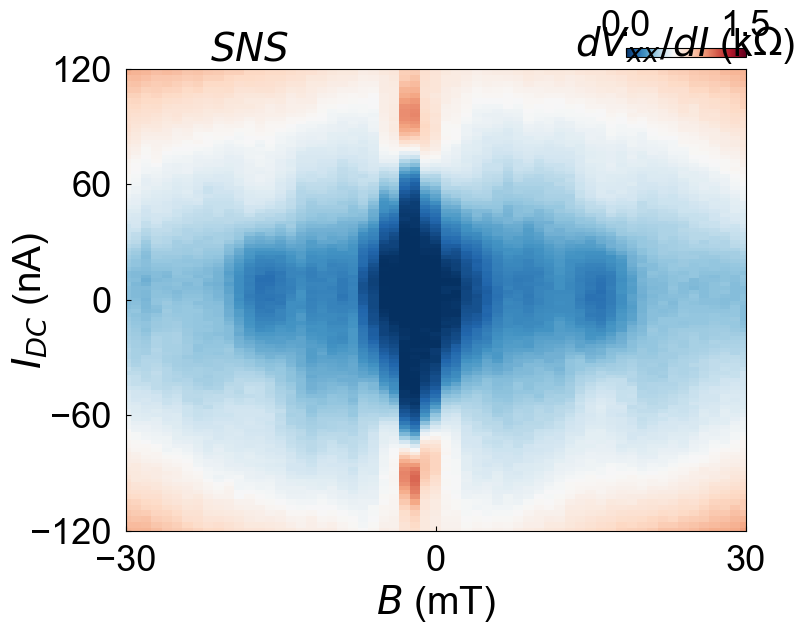

In [20]:

# Data
num=0
x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm

# Fig params to save and color 

font = 26

if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

fig = plt.figure(figsize=(8,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=1.5)

ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font+2,labelpad=-15)
ax.set_xlabel('$B$ (mT)',fontsize=font+2)
#ax.yaxis.set_label_coords(-0.1,0.5)
#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=10)
ax.set_xticks([-60,-30,0,30,60])
ax.set_yticks([-120,-60,0,120,60])
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font+2,position=(-0.75,1), labelpad=-24,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')
cb.set_ticks([0,1.5])
ax.set_ylim(-120,120)
ax.set_xlim(-30,30)
#ax.set_title('$SNcS$ $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.45,0.92),color='k',bbox=dict(facecolor='w',edgecolor='k'))
ax.set_title('$SNS$',fontsize=font+2,position=(0.2,0.85),color='k',weight='bold')

ax.plot(-44,100,'aqua',marker='o',markersize=20)
'''
ax.annotate('B ', xy=(80,-140),
            xytext=(50, -140),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font+2
            )
'''
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SNS_Vbg-1p48_focus_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
plt.show()

# Plot the line at 0 field
plt.figure(figsize=(10,6))
line=58
plt.plot(x[line],z1517[line],'k',label='$B$='+'{0:.2f}'.format(y[line,0])+' mT')


#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
plt.title('$SNS, V_{BG}:-1.48$ V, $V_{TGs}:'+'{0:.2f}'.format(-(-1.48+1.25)/0.88)+'$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))

plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font)
plt.ylim(-0.5,55)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SNS_Vbg-1p48_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()


# SSS

In [ ]:
savecount=1
# Data
num=1

x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm
z1517R=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10R/I718/1000/10 # in kOhm

# Fig params to save and color 

font = 26

if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

#mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

# Start the focused figure 

mycolor=LDQM_dataplot.shiftedColorMap(0.1,orig_cmap,division=1024)

fig = plt.figure(figsize=(12,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=40,shading='gouraud')

ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font+2,labelpad=-15)
ax.set_xlabel('$B$ (mT)',fontsize=font+2)


ax.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=10)
ax.set_yticks([-300,-150,0,150,300])
#ax.set_xticks([-200,-100,0,100,200])
ax.set_xticks([-60,-30,0,30,60])
ax.set_ylim(-300,300)
ax.set_xlim(-30,30)
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font+2,position=(-0.7,1), labelpad=-24,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')
cb.set_ticks([0,40])
#ax.set_xlim(-200,200)

#ax.set_title('$SNcS$ $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.45,0.92),color='k',bbox=dict(facecolor='w',edgecolor='k'))
ax.set_title('$SSS$',fontsize=font+2,position=(0.2,0.85),color='k',weight='bold')
ax.plot(-45,237,'limegreen',marker='o',markersize=20)
'''
ax.annotate('B ', xy=(150,-210),
            xytext=(100, -210),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font+2
            )
'''
#ax.tight_layout()
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_focus_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
plt.show()

# Plot the line at 0 field
plt.figure(figsize=(10,6))
line=63
plt.plot(x[line],z1517[line],'k',label='$B$='+'{0:.2f}'.format(y[line,0])+' mT')


#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
plt.title('$SCS, V_{BG}:-1.25$ V, $V_{TGs}:'+'{0:.2f}'.format(-(-1.25+1.25)/0.88)+'$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))

plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font,direction='in')
plt.ylim(-.5,60)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)
plt.tight_layout()
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()




In [ ]:
font=15
ax=plot_pre(6,4)
ax.plot(x[line0],z1517R[line0],'k',label='$B$='+'{0:.2f}'.format(y[line0,0])+' mT')
ax.plot(x[line1],z1517R[line1],'r',label='$B$='+'{0:.2f}'.format(y[line1,0])+' mT')
ax.plot(x[line2],z1517R[line2],'b',label='$B$='+'{0:.2f}'.format(y[line2,0])+' mT')
plot_line(ax,xlabel='$I_{dc}$ (nA)',ylabel='$dV_{xx}/dI$ (k$\Omega$)')
ax.tick_params(axis='x', which='minor', direction='in')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1), shadow=False, ncol=1,fontsize=font,frameon=False,
          labelspacing=0.25,columnspacing=0)
ax.xaxis.set_minor_locator(mticker.MultipleLocator(50))
ax.set_yscale('log')
ax.axvline(x=50,linestyle='dashed',color='gray',linewidth=1)
ax.axvline(x=-50,linestyle='dashed',color='gray',linewidth=1)
ax.plot(50,0.4,marker='o',color='r',markersize=6)
ax.plot(-50,0.4,marker='o',color='r',markersize=6)
ax.set_ylim(0.01,100)
plt.tight_layout()

plt.show()

In [ ]:
ax=plot_pre(6,4)
ax.plot(x[line0],z1517R[line0],'k',label='$B$='+'{0:.2f}'.format(y[line0,0])+' mT')
ax.plot(x[line1],z1517R[line1],'r',label='$B$='+'{0:.2f}'.format(y[line1,0])+' mT')
ax.plot(x[line2],z1517R[line2],'b',label='$B$='+'{0:.2f}'.format(y[line2,0])+' mT')
plot_line(ax,xlabel='$I_{dc}$ (nA)',ylabel='$dV_{xx}/dI$ (k$\Omega$)')
ax.tick_params(axis='x', which='minor', direction='in')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1), shadow=False, ncol=1,fontsize=font,frameon=False,
          labelspacing=0.25,columnspacing=0)
ax.xaxis.set_minor_locator(mticker.MultipleLocator(50))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(10))
#ax.set_yscale('log')
#ax.axvline(x=50,linestyle='dashed',color='gray',linewidth=1)
#ax.axvline(x=-50,linestyle='dashed',color='gray',linewidth=1)
#ax.plot(50,0.4,marker='o',color='r',markersize=6)
#ax.plot(-50,0.4,marker='o',color='r',markersize=6)
plt.tight_layout()
plt.show()

In [ ]:
# Plot the line at 0 field
plt.figure(figsize=(7,5))
line2=10
line1=23
line0=63
plt.plot(x[line0],z1517R[line0],'k',label='$B$='+'{0:.2f}'.format(y[line0,0])+' mT')
plt.plot(x[line1],z1517R[line1],'r',label='$B$='+'{0:.2f}'.format(y[line1,0])+' mT')
plt.plot(x[line2],z1517R[line2],'b',label='$B$='+'{0:.2f}'.format(y[line2,0])+' mT')

#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
#plt.title('$SCS, V_{BG}:-1.25$ V, $V_{TGs}:'+'{0:.2f}'.format(-(-1.25+1.25)/0.88)+'$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))

plt.xlabel('$I$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font,direction='in')

plt.axvline(x=50,linestyle='dashed',color='gray',linewidth=1)
plt.axvline(x=-50,linestyle='dashed',color='gray',linewidth=1)
plt.axvline(x=250,linestyle='dashed',color='gray',linewidth=1)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)
plt.tight_layout()
ax.set_ylim(0.02,1000)
plt.yscale('log')
#plt.ylim(-.5,60)
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()


In [ ]:
# Plot the line at 0 field
plt.figure(figsize=(7,5))
line2=10
line1=23
line0=63
plt.plot(x[line0],z1517[line0],'k',label='$B$='+'{0:.2f}'.format(y[line0,0])+' mT')
plt.plot(x[line1],z1517[line1],'r',label='$B$='+'{0:.2f}'.format(y[line1,0])+' mT')
plt.plot(x[line2],z1517[line2],'b',label='$B$='+'{0:.2f}'.format(y[line2,0])+' mT')

#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
#plt.title('$SCS, V_{BG}:-1.25$ V, $V_{TGs}:'+'{0:.2f}'.format(-(-1.25+1.25)/0.88)+'$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))

plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font,direction='in')

plt.axvline(x=50,linestyle='dashed',color='gray',linewidth=1)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.yscale('log')
#plt.ylim(-.5,60)
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()



In [87]:
from matplotlib.colors import SymLogNorm

In [177]:
x[0,1]

-312.0

In [204]:
from matplotlib import colors

In [224]:
5/50

0.1

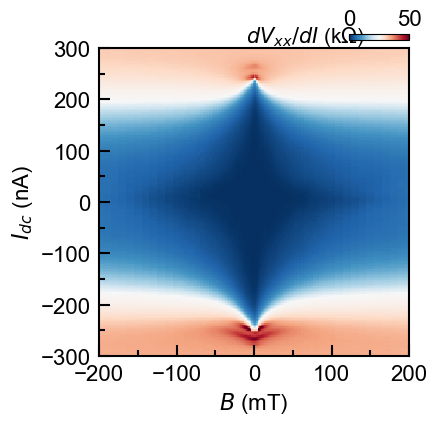

In [230]:
savecount=0
# Data
num=1

x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm

# Fig params to save and color 

font = 26

if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

#mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

# Start the focused figure 

mycolor=shiftedColorMap(0.1,orig_cmap,division=512,start=0,stop=1)

divnorm=colors.TwoSlopeNorm(vmin=0, vcenter=5, vmax=50)

ax,fig=plot_premap(4,4)
#im=plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=50,rasterized=True)
im=plt.pcolormesh(y,x,z1517,cmap='RdBu_r',norm=divnorm,rasterized=True)

plot_map(ax,im,fig,xlabel='$B$ (mT)',ylabel='$I_{dc}$ (nA)')
ax.text(-10,312,'$dV_{xx}/dI$ (k$\Omega$)',fontsize=15)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(50))
ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(50))
ax.set_ylim(-300,300)
ax.set_xlim(-200,200)
if save:
    plt.savefig(savename+'Fraunhofer'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'Fraunhofer'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=300) 
    savecount=savecount+1
plt.show()

In [221]:
savename='C:/jdiez_local/LDQM/g. Manuscript/TBG_Fab/Figures/Fig1/'

In [166]:
def shiftedColorMap(midpoint=0.5,cmap=orig_cmap, start=0,  stop=1.0,
                    division=258,name='shiftedcmap'):

    cdict = {
        'red': [],
        'green': [],
        'blue': [],
        'alpha': []
    }

    # regular index to compute the colors
    reg_index = np.linspace(start, stop, division)
    
    # shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, int(division/2), endpoint=False), 
        np.linspace(midpoint, 1.0, int(division/2), endpoint=True)
    ])

    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)
        
        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))

    newcmap = matplotlib.colors.LinearSegmentedColormap(name, cdict)
    #plt.register_cmap(cmap=newcmap)

    return newcmap

In [163]:
np.linspace(0.5, 1.0, 15)

array([0.5       , 0.53571429, 0.57142857, 0.60714286, 0.64285714,
       0.67857143, 0.71428571, 0.75      , 0.78571429, 0.82142857,
       0.85714286, 0.89285714, 0.92857143, 0.96428571, 1.        ])